# Watermarking Benchmark
Modular, reproducible benchmark for comparing watermarking methods under geometric
and photometric attacks.

**Sections**
1. Setup
2. Image loading
3. Helpers
4. Models
5. Attacks
6. Evaluation
7. Parameter grid
8. Global benchmark
9. Visualisation


## 1 · Setup

In [40]:
import sys, time, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from skimage import img_as_ubyte, img_as_float64
from skimage.io import imread
from skimage.color import rgb2gray, gray2rgb
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.transform import (
    rotate, rescale, resize, warp, AffineTransform, ProjectiveTransform,
)
from skimage.filters import gaussian, unsharp_mask
from skimage.exposure import adjust_gamma, rescale_intensity
from skimage.util import random_noise

warnings.filterwarnings("ignore")

# ── Deterministic global seed ───────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ───────────────────────────────────────────────────────────────────
ROOT      = Path(".")
IMG_DIR   = ROOT / "img"
SYS_PATHS = [str(ROOT)]          # add project root so local modules resolve
for p in SYS_PATHS:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── Matplotlib style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":     120,
    "font.size":      10,
    "axes.titlesize": 11,
    "axes.grid":      False,
})

print("Setup complete.")


Setup complete.


## 2 · Image loading

In [41]:
def load_images(directory: Path, exclude: str = "_old") -> dict[str, np.ndarray]:
    """
    Load all images from *directory*, skipping sub-folders named *exclude*.

    Images are returned as uint8 arrays (grayscale kept as 2-D, RGB as 3-D).
    Supported extensions: png, jpg, jpeg, bmp, tiff, tif.

    Parameters
    ----------
    directory : Path
        Folder to scan recursively.
    exclude : str
        Sub-folder name to skip (default ``"_old"``).

    Returns
    -------
    images : dict[str, ndarray]
        Mapping from stem filename to uint8 array.
    """
    EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif"}
    images: dict[str, np.ndarray] = {}

    paths = sorted(directory.rglob("*")) if directory.exists() else []
    for path in paths:
        if exclude in path.parts:
            continue
        if path.suffix.lower() not in EXTS:
            continue
        img = imread(str(path))
        if img.ndim == 2:                           # grayscale
            images[path.stem] = img_as_ubyte(img)
        elif img.ndim == 3 and img.shape[2] == 4:  # RGBA → RGB
            images[path.stem] = img_as_ubyte(img[..., :3])
        elif img.ndim == 3:
            images[path.stem] = img_as_ubyte(img)

    return images


images = load_images(IMG_DIR)

if images:
    print(f"Loaded {len(images)} image(s): {list(images.keys())}")
else:
    # ── Synthetic fallback: generate test images ─────────────────────────
    print("No images found in img/ — generating synthetic test images.")
    rng = np.random.default_rng(SEED)
    images = {
        "synthetic_gray": rng.integers(0, 256, (256, 256),    dtype=np.uint8),
        "synthetic_rgb":  rng.integers(0, 256, (256, 256, 3), dtype=np.uint8),
    }
    print(f"Generated {len(images)} synthetic image(s).")


Loaded 5 image(s): ['airplane', 'baboon', 'cameraman', 'man', 'tangled_small']


## 3 · Helpers

In [42]:
# ── Watermark generation ────────────────────────────────────────────────────

def make_watermark(n_bits: int, seed: int = SEED) -> np.ndarray:
    """
    Generate a deterministic binary watermark.

    Parameters
    ----------
    n_bits : int
    seed   : int

    Returns
    -------
    wm : ndarray of shape (n_bits,), dtype uint8, values in {0, 1}
    """
    return np.random.default_rng(seed).integers(0, 2, n_bits, dtype=np.uint8)


# ── BER ─────────────────────────────────────────────────────────────────────

def ber(original: np.ndarray, decoded: np.ndarray) -> float:
    """
    Bit Error Rate between two binary arrays.

    Parameters
    ----------
    original : ndarray of shape (n,), dtype int
    decoded  : ndarray of shape (n,), dtype int

    Returns
    -------
    ber : float in [0, 1]
    """
    return float(np.mean(original != decoded))


# ── Timing ──────────────────────────────────────────────────────────────────

def timed_encode(model, image: np.ndarray, watermark: np.ndarray) -> tuple:
    """
    Encode *watermark* into *image* and return (watermarked_image, elapsed_s).
    """
    t0 = time.perf_counter()
    wm_img = model.encode(image, watermark)
    return wm_img, time.perf_counter() - t0


def timed_decode(model, image: np.ndarray, n_bits: int) -> tuple:
    """
    Decode watermark from *image* and return (bits, confidence, elapsed_s).
    """
    t0 = time.perf_counter()
    bits, conf = model.decode(image, n_bits)
    return bits, conf, time.perf_counter() - t0


# ── PSNR helper ─────────────────────────────────────────────────────────────

def compute_psnr(reference: np.ndarray, distorted: np.ndarray) -> float:
    """
    PSNR between *reference* and *distorted* (both uint8).
    Returns ``np.inf`` when images are identical.
    """
    try:
        return float(psnr(reference, distorted, data_range=255))
    except Exception:
        return float("inf")


# ── Display helpers ──────────────────────────────────────────────────────────

def show_images(images: dict[str, np.ndarray], max_cols: int = 4) -> None:
    """Display a gallery of images."""
    n    = len(images)
    cols = min(n, max_cols)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()
    for ax, (name, img) in zip(axes, images.items()):
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(name, fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def show_watermark(wm: np.ndarray) -> None:
    """Display binary watermark as a 1-D bar."""
    fig, ax = plt.subplots(figsize=(8, 0.6))
    ax.imshow(wm[np.newaxis], aspect="auto", cmap="binary", vmin=0, vmax=1)
    ax.set_yticks([])
    ax.set_xlabel("Bit index")
    ax.set_title("Watermark")
    plt.tight_layout()
    plt.show()


# ── Single evaluation ────────────────────────────────────────────────────────

def evaluate(
    model,
    model_name: str,
    config: dict,
    image: np.ndarray,
    image_name: str,
    watermark: np.ndarray,
    attack_fn,
    attack_name: str,
) -> dict:
    """
    Run one encode→attack→decode cycle and collect metrics.

    Parameters
    ----------
    model       : object with `.encode` and `.decode` methods
    model_name  : str
    config      : dict of hyperparameters (for logging)
    image       : ndarray, uint8
    image_name  : str
    watermark   : ndarray of shape (n_bits,), uint8
    attack_fn   : callable(image) → image
    attack_name : str

    Returns
    -------
    record : dict with keys
        model, config, image, attack, ber, psnr, encode_time, decode_time
    """
    n_bits = len(watermark)

    # Encode
    wm_img, t_enc = timed_encode(model, image, watermark)

    # Attack
    attacked = attack_fn(wm_img)

    # Decode
    bits, conf, t_dec = timed_decode(model, attacked, n_bits)

    return {
        "model":       model_name,
        "config":      str(config),
        "image":       image_name,
        "attack":      attack_name,
        "ber":         ber(watermark, bits),
        "confidence":  conf,
        "psnr":        compute_psnr(image, wm_img),
        "encode_time": t_enc,
        "decode_time": t_dec,
    }


print("Helpers defined.")


Helpers defined.


## 4 · Models

In [43]:
from lsb.model import encode as lsb_encode, decode as lsb_decode


class WatermarkModel:
    """
    Generic watermark model wrapper.

    Separates encode-time and decode-time keyword arguments so that
    decoder-only options (e.g. ``sync_enabled``) are not forwarded to
    the encoder — keeping each function signature clean.

    Parameters
    ----------
    encode_fn  : callable(image, watermark, **encode_kw) → ndarray
    decode_fn  : callable(image, n_bits, **decode_kw) → (bits, confidence)
    encode_kw  : dict
        Keyword arguments forwarded exclusively to *encode_fn*.
    decode_kw  : dict
        Keyword arguments forwarded exclusively to *decode_fn*.
    """

    def __init__(
        self,
        encode_fn,
        decode_fn,
        encode_kw: dict | None = None,
        decode_kw: dict | None = None,
    ):
        self._encode    = encode_fn
        self._decode    = decode_fn
        self._encode_kw = encode_kw or {}
        self._decode_kw = decode_kw or {}

    def encode(self, image: np.ndarray, watermark: np.ndarray) -> np.ndarray:
        """Embed *watermark* into *image* using encode-time kwargs."""
        return self._encode(image, watermark, **self._encode_kw)

    def decode(self, image: np.ndarray, n_bits: int) -> tuple:
        """Recover watermark from *image* (returns bits + confidence)."""
        return self._decode(image, n_bits, **self._decode_kw)


# ── Model registry (add new methods here) ───────────────────────────────────
# Populated later from param_grid — placeholder shown for clarity.
# models = {
#     "lsb_p16": WatermarkModel(
#         lsb_encode, lsb_decode,
#         encode_kw=dict(patch_size=16, key=SEED),
#         decode_kw=dict(patch_size=16, key=SEED, sync_enabled=False),
#     ),
# }

print("WatermarkModel class defined.")


WatermarkModel class defined.


## 5 · Attacks

In [44]:
# All attack functions: ndarray (uint8) → ndarray (uint8).
# They are deterministic and stateless (any randomness uses a fixed seed).

_NOISE_RNG = np.random.default_rng(SEED)   # shared RNG for noisy attacks


def _to_u8(img: np.ndarray) -> np.ndarray:
    """Clip + convert float/any array to uint8."""
    return img_as_ubyte(np.clip(img_as_float64(img), 0, 1))


# ── Geometric ────────────────────────────────────────────────────────────────

def attack_rotate(img: np.ndarray, angle: float = 15.0) -> np.ndarray:
    """Rotate by *angle* degrees (anti-clockwise, reflect padding)."""
    return _to_u8(rotate(img_as_float64(img), angle, mode="reflect", order=0, preserve_range=True))


def attack_scale(img: np.ndarray, factor: float = 0.8) -> np.ndarray:
    """Rescale by *factor* then crop / pad to original size."""
    H, W   = img.shape[:2]
    scaled = rescale(img_as_float64(img), factor,
                     channel_axis=2 if img.ndim == 3 else None,
                     anti_aliasing=True)
    sh, sw = scaled.shape[:2]
    # Centre-crop or centre-pad
    out = np.zeros_like(img_as_float64(img))
    r0  = max(0, (H - sh) // 2);  c0 = max(0, (W - sw) // 2)
    sr0 = max(0, (sh - H) // 2);  sc0 = max(0, (sw - W) // 2)
    rh  = min(sh, H);              cw = min(sw, W)
    out[r0:r0 + rh, c0:c0 + cw] = scaled[sr0:sr0 + rh, sc0:sc0 + cw]
    return _to_u8(out)


def attack_crop(img: np.ndarray, fraction: float = 0.1) -> np.ndarray:
    """Crop *fraction* from each border, resize back to original."""
    H, W = img.shape[:2]
    dy, dx = int(H * fraction), int(W * fraction)
    cropped = img[dy:H - dy, dx:W - dx]
    resized = resize(img_as_float64(cropped), (H, W), anti_aliasing=True)
    return _to_u8(resized)


def attack_flip(img: np.ndarray) -> np.ndarray:
    """Horizontal flip."""
    return np.ascontiguousarray(img[:, ::-1])


def attack_shift(img: np.ndarray, shift: int = 10) -> np.ndarray:
    """Translate by (*shift*, *shift*) pixels (wrap-around)."""
    return np.roll(img, (shift, shift), axis=(0, 1))


def attack_perspective(img: np.ndarray, strength: float = 0.05) -> np.ndarray:
    """
    Apply a mild projective (perspective) distortion.

    The four corners are displaced by *strength* × min(H,W) pixels.
    """
    H, W  = img.shape[:2]
    d     = strength * min(H, W)
    src   = np.array([[0, 0], [W, 0], [W, H], [0, H]], dtype=float)
    dst   = src + np.array([[-d, -d], [d, -d], [-d, d], [d, d]])
    tform = ProjectiveTransform()
    tform.estimate(src, dst)
    warped = warp(img_as_float64(img), tform.inverse,
                  output_shape=(H, W), mode="edge")
    return _to_u8(warped)


def attack_resize(img: np.ndarray, factor: float = 0.5) -> np.ndarray:
    """Downscale then upscale to original size (lossy round-trip)."""
    H, W     = img.shape[:2]
    small    = resize(img_as_float64(img),
                      (max(1, int(H * factor)), max(1, int(W * factor))),
                      anti_aliasing=True)
    restored = resize(small, (H, W), anti_aliasing=True)
    return _to_u8(restored)


# ── Photometric ───────────────────────────────────────────────────────────────

def attack_noise(img: np.ndarray, var: float = 0.005) -> np.ndarray:
    """Add Gaussian noise with variance *var*."""
    noisy = random_noise(img_as_float64(img), mode="gaussian",
                         var=var, rng=SEED)
    return _to_u8(noisy)


def attack_jpeg(img: np.ndarray, quality: int = 50) -> np.ndarray:
    """
    JPEG-like compression via DCT quantisation simulation.

    Implemented as a repeated downsample + upsample with a blur to avoid
    pulling in PIL/Pillow as a hard dependency.
    """
    import io
    try:
        from PIL import Image as PILImage
        buf = io.BytesIO()
        pil = PILImage.fromarray(img)
        pil.save(buf, format="JPEG", quality=quality)
        buf.seek(0)
        return np.array(PILImage.open(buf))
    except ImportError:
        # Fallback: blur + quantise to simulate blockiness
        blurred = gaussian(img_as_float64(img), sigma=1 + (100 - quality) / 50)
        q       = max(1, (100 - quality) // 10)
        quantised = (np.floor(blurred * 255 / q) * q / 255)
        return _to_u8(np.clip(quantised, 0, 1))


def attack_blur(img: np.ndarray, sigma: float = 2.0) -> np.ndarray:
    """Gaussian blur with standard deviation *sigma*."""
    return _to_u8(gaussian(img_as_float64(img), sigma=sigma,
                           channel_axis=2 if img.ndim == 3 else None))


def attack_sharpen(img: np.ndarray, amount: float = 2.0) -> np.ndarray:
    """Unsharp-mask sharpening."""
    return _to_u8(unsharp_mask(img_as_float64(img), radius=2, amount=amount,
                               channel_axis=2 if img.ndim == 3 else None))


def attack_contrast(img: np.ndarray, gain: float = 1.5) -> np.ndarray:
    """Linear contrast adjustment (multiply pixel values by *gain*)."""
    return _to_u8(np.clip(img_as_float64(img) * gain, 0, 1))


def attack_brightness(img: np.ndarray, offset: float = 0.15) -> np.ndarray:
    """Add a constant brightness offset."""
    return _to_u8(np.clip(img_as_float64(img) + offset, 0, 1))


def attack_gamma(img: np.ndarray, gamma: float = 1.8) -> np.ndarray:
    """Apply gamma correction."""
    return _to_u8(adjust_gamma(img_as_float64(img), gamma=gamma))


def attack_color_convert(img: np.ndarray) -> np.ndarray:
    """Convert to grayscale then back to the original colour mode."""
    f    = img_as_float64(img)
    grey = rgb2gray(f) if f.ndim == 3 else f
    out  = gray2rgb(grey) if img.ndim == 3 else grey
    return _to_u8(out)


def attack_hue_saturation(img: np.ndarray, hue_shift: float = 0.1,
                           sat_scale: float = 1.3) -> np.ndarray:
    """
    Shift hue and scale saturation (RGB images only).
    Grayscale images are returned unchanged.
    """
    if img.ndim == 2:
        return img
    from skimage.color import rgb2hsv, hsv2rgb
    hsv             = rgb2hsv(img_as_float64(img))
    hsv[..., 0]     = (hsv[..., 0] + hue_shift) % 1.0
    hsv[..., 1]     = np.clip(hsv[..., 1] * sat_scale, 0, 1)
    return _to_u8(hsv2rgb(hsv))


def attack_none(img: np.ndarray) -> np.ndarray:
    """Identity — no transformation (baseline)."""
    return img.copy()


# ── Attack registry (add new attacks here) ───────────────────────────────────
ATTACKS: dict[str, callable] = {
    "none":          attack_none,
    "rotate_15":     lambda x: attack_rotate(x, 15.0),
    "scale_0.8":     lambda x: attack_scale(x, 0.8),
    "crop_10%":      lambda x: attack_crop(x, 0.10),
    "flip":          attack_flip,
    "shift_10px":    lambda x: attack_shift(x, 10),
    "perspective":   attack_perspective,
    "resize_0.5":    lambda x: attack_resize(x, 0.5),
    "noise_low":     lambda x: attack_noise(x, 0.001),
    "noise_high":    lambda x: attack_noise(x, 0.01),
    "jpeg_q50":      lambda x: attack_jpeg(x, 50),
    "jpeg_q80":      lambda x: attack_jpeg(x, 80),
    "blur_s1":       lambda x: attack_blur(x, 1.0),
    "blur_s3":       lambda x: attack_blur(x, 3.0),
    "sharpen":       attack_sharpen,
    "contrast_1.5":  lambda x: attack_contrast(x, 1.5),
    "brightness+":   lambda x: attack_brightness(x, 0.15),
    "gamma_1.8":     lambda x: attack_gamma(x, 1.8),
    "color_convert": attack_color_convert,
    "hue_sat":       attack_hue_saturation,
}

print(f"{len(ATTACKS)} attacks registered.")


20 attacks registered.


## 6 · Evaluation function

In [45]:
def run_benchmark(
    models: dict,
    images: dict[str, np.ndarray],
    attacks: dict[str, callable],
    watermark: np.ndarray,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Run the full benchmark matrix: models × images × attacks.

    Parameters
    ----------
    models    : dict[str, WatermarkModel]
    images    : dict[str, ndarray]
    attacks   : dict[str, callable]
    watermark : ndarray of shape (n_bits,), dtype uint8
    verbose   : bool
        Print progress to stdout.

    Returns
    -------
    results : pd.DataFrame
        One row per (model, image, attack) combination with columns:
        model, config, image, attack, ber, confidence, psnr,
        encode_time, decode_time.
    """
    records = []
    total   = len(models) * len(images) * len(attacks)
    done    = 0

    for model_name, model in models.items():
        for img_name, img in images.items():
            for atk_name, atk_fn in attacks.items():
                record = evaluate(
                    model, model_name, {},
                    img, img_name,
                    watermark,
                    atk_fn, atk_name,
                )
                records.append(record)
                done += 1
                if verbose:
                    print(f"  [{done:4d}/{total}]  {model_name:<30s}  "
                          f"{img_name:<20s}  {atk_name:<18s}  "
                          f"BER={record['ber']:.3f}", end="\r")

    if verbose:
        print()
    return pd.DataFrame(records)


print("run_benchmark() defined.")


run_benchmark() defined.


## 7 · Parameter grid

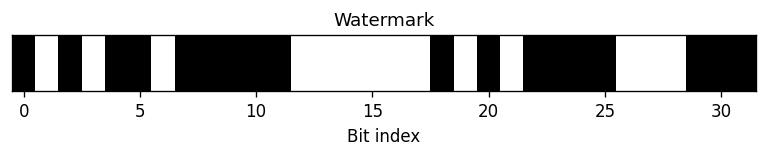

4 model configurations created:
  lsb_p=32_t=normal_s=False
  lsb_p=32_t=normal_s=True
  lsb_p=32_t=symmetric_s=False
  lsb_p=32_t=symmetric_s=True


In [46]:
# ── Watermark ────────────────────────────────────────────────────────────────
N_BITS    = 32
watermark = make_watermark(N_BITS, seed=SEED)
show_watermark(watermark)

# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = {
    "patch_size":    [32],
    "tile_mode":     ["normal", "symmetric"],
    "sync_enabled":  [False, True],
}

# Generate all combinations and instantiate models
models: dict[str, WatermarkModel] = {}
for values in itertools.product(*param_grid.values()):
    cfg = dict(zip(param_grid.keys(), values))
    name = "lsb_" + "_".join(f"{k[0]}={v}" for k, v in cfg.items())
    shared_kw = dict(patch_size=cfg["patch_size"], key=SEED,
                     tile_mode=cfg["tile_mode"])
    models[name] = WatermarkModel(
        lsb_encode,
        lsb_decode,
        encode_kw=shared_kw,
        decode_kw={**shared_kw, "sync_enabled": cfg["sync_enabled"]},
    )

print(f"{len(models)} model configurations created:")
for k in models:
    print(f"  {k}")


## 8 · Run benchmark

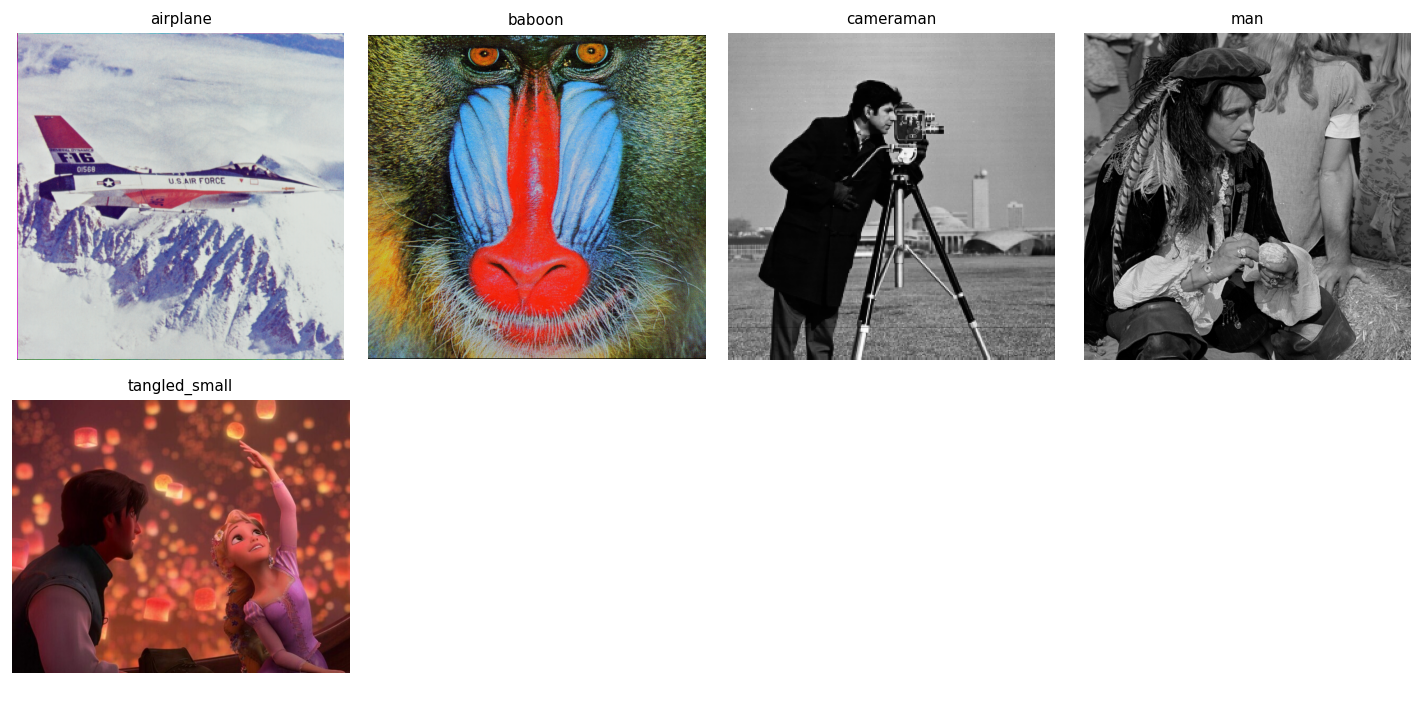


Running benchmark: 4 configs × 5 images × 20 attacks …

Estimated rotation: 15.0°, scale: 1.0e        airplane              none                BER=0.000
Estimated rotation: -4.0°, scale: 1.0e        airplane              rotate_15           BER=0.000
Estimated rotation: 22.0°, scale: 1.0e        airplane              scale_0.8           BER=0.562
Estimated rotation: -1.0°, scale: 1.0e        airplane              shift_10px          BER=0.531
Estimated rotation: -17.0°, scale: 1.0        airplane              perspective         BER=0.406
Estimated rotation: 47.0°, scale: 1.0e        airplane              resize_0.5          BER=0.344
Estimated rotation: -82.0°, scale: 1.0        airplane              noise_low           BER=0.500
Estimated rotation: -1.0°, scale: 1.0e        airplane              noise_high          BER=0.406
Estimated rotation: 86.0°, scale: 1.0e        airplane              jpeg_q50            BER=0.500
Estimated rotation: 4.0°, scale: 1.0ue        airplane       

,model,config,image,attack,ber,confidence,psnr,encode_time,decode_time
0,lsb_p=32_t=normal_s=False,{},airplane,none,0.00000,1.000000,55.91056,0.005304,0.006757
1,lsb_p=32_t=normal_s=False,{},airplane,rotate_15,0.34375,0.069580,55.91056,0.004531,0.003318
2,lsb_p=32_t=normal_s=False,{},airplane,scale_0.8,0.56250,0.383057,55.91056,0.001855,0.003537
3,lsb_p=32_t=normal_s=False,{},airplane,crop_10%,0.56250,0.051514,55.91056,0.001635,0.003403
4,lsb_p=32_t=normal_s=False,{},airplane,flip,0.40625,1.000000,55.91056,0.001874,0.007324
5,lsb_p=32_t=normal_s=False,{},airplane,shift_10px,0.53125,1.000000,55.91056,0.001675,0.006009
6,lsb_p=32_t=normal_s=False,{},airplane,perspective,0.56250,0.058350,55.91056,0.001706,0.003384
7,lsb_p=32_t=normal_s=False,{},airplane,resize_0.5,0.34375,0.070312,55.91056,0.001529,0.006398
8,lsb_p=32_t=normal_s=False,{},airplane,noise_low,0.62500,0.041992,55.91056,0.004971,0.005088
9,lsb_p=32_t=normal_s=False,{},airplane,noise_high,0.28125,0.050537,55.91056,0.001674,0.003258


In [47]:
show_images(images)

print(f"\nRunning benchmark: {len(models)} configs × "
      f"{len(images)} images × {len(ATTACKS)} attacks …\n")

results = run_benchmark(models, images, ATTACKS, watermark, verbose=True)

print(f"\n{len(results)} records collected.")
results.head(10)


## 9 · Global summary

In [48]:
# Mean BER per (model, config) across all attacks and images
summary = (
    results
    .groupby(["model", "config"])
    .agg(
        mean_ber=("ber",         "mean"),
        std_ber=("ber",          "std"),
        mean_psnr=("psnr",       "mean"),
        mean_enc_ms=("encode_time", lambda x: x.mean() * 1000),
        mean_dec_ms=("decode_time", lambda x: x.mean() * 1000),
    )
    .reset_index()
    .sort_values("mean_ber")
)

print("Top 10 configurations by mean BER (lower = more robust):")
display(summary.head(10).to_string(index=False))


Top 10 configurations by mean BER (lower = more robust):


'                       model config  mean_ber  std_ber  mean_psnr  mean_enc_ms  mean_dec_ms\n    lsb_p=32_t=normal_s=True     {}  0.411250 0.241642  53.999529     2.407139   331.516133\n   lsb_p=32_t=normal_s=False     {}  0.428750 0.224561  53.999529     2.447803     5.828160\n lsb_p=32_t=symmetric_s=True     {}  0.452813 0.132842  54.007412     2.868511   407.957248\nlsb_p=32_t=symmetric_s=False     {}  0.475000 0.126880  54.007412     2.063712     5.496795'

## 10 · Visualisation — BER heatmap

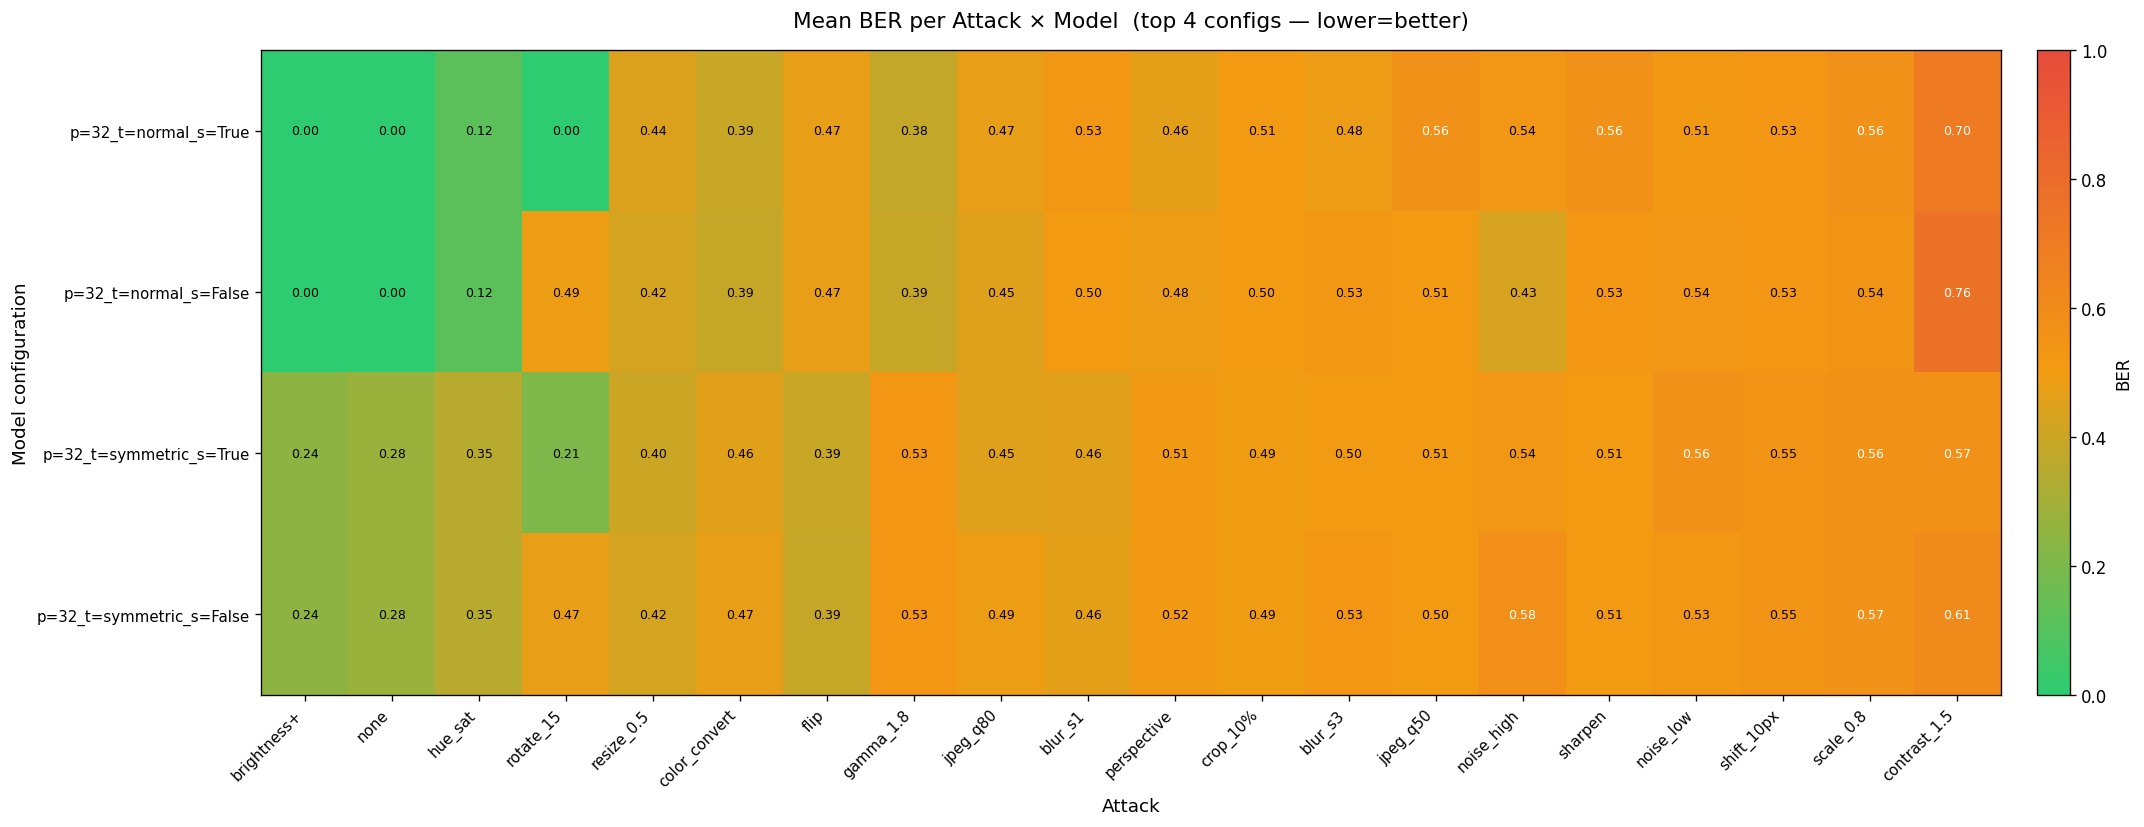

In [49]:
def plot_ber_heatmap(
    results: pd.DataFrame,
    top_n: int = 10,
    figsize: tuple = (18, 7),
) -> None:
    """
    Plot a BER heatmap: rows = best model configs, columns = attacks.

    Colour scale: green (BER=0, robust) → red (BER=1, broken).

    Parameters
    ----------
    results : pd.DataFrame
        Output of :func:`run_benchmark`.
    top_n   : int
        Number of best configurations to display (sorted by mean BER).
    figsize : (width, height)
    """
    # Select top_n best configs by mean BER
    best_configs = (
        results
        .groupby("model")["ber"]
        .mean()
        .sort_values()
        .head(top_n)
        .index.tolist()
    )

    pivot = (
        results[results["model"].isin(best_configs)]
        .groupby(["model", "attack"])["ber"]
        .mean()
        .unstack("attack")
    )
    # Reorder rows by mean BER (best on top)
    pivot = pivot.loc[best_configs]

    # Sort columns by mean BER (easiest attacks first)
    pivot = pivot[pivot.mean().sort_values().index]

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "ber_cmap", ["#2ecc71", "#f39c12", "#e74c3c"]
    )

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, vmin=0, vmax=1)

    # Axes labels
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(
        [m.replace("lsb_", "") for m in pivot.index], fontsize=9
    )
    ax.set_xlabel("Attack", fontsize=11)
    ax.set_ylabel("Model configuration", fontsize=11)
    ax.set_title(
        f"Mean BER per Attack × Model  (top {top_n} configs — lower=better)",
        fontsize=13, pad=14,
    )

    # Cell annotations
    for r, row in enumerate(pivot.values):
        for c, val in enumerate(row):
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=7.5,
                    color="white" if val > 0.55 else "black")

    plt.colorbar(im, ax=ax, label="BER", fraction=0.025, pad=0.02)
    plt.tight_layout()
    plt.show()


plot_ber_heatmap(results, top_n=min(10, len(models)))


## 11 · Per-attack BER — best configuration

Best configuration: lsb_p=32_t=normal_s=True


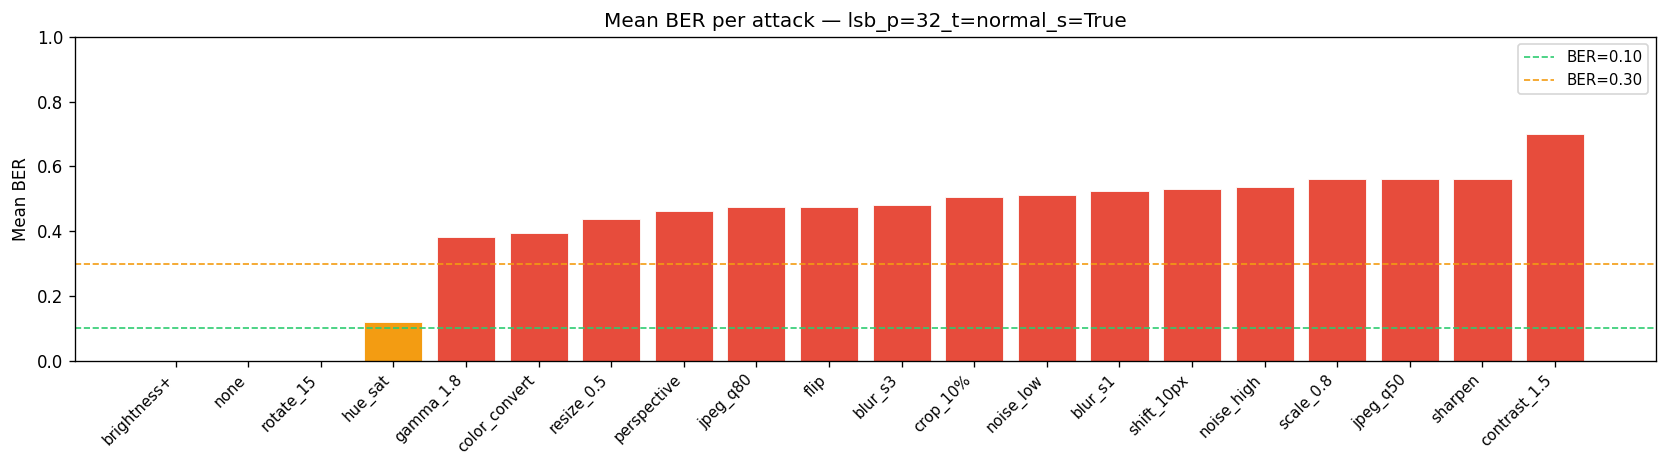

In [50]:
def plot_attack_bars(results: pd.DataFrame, model_name: str) -> None:
    """
    Bar chart of mean BER per attack for a single model configuration.

    Parameters
    ----------
    results    : pd.DataFrame
    model_name : str
    """
    sub  = results[results["model"] == model_name]
    data = sub.groupby("attack")["ber"].mean().sort_values()

    fig, ax = plt.subplots(figsize=(14, 4))
    colours = ["#2ecc71" if v < 0.1 else "#f39c12" if v < 0.3 else "#e74c3c"
               for v in data.values]
    ax.bar(data.index, data.values, color=colours, edgecolor="white", linewidth=0.5)
    ax.axhline(0.1,  color="#2ecc71", linestyle="--", linewidth=1, label="BER=0.10")
    ax.axhline(0.3,  color="#f39c12", linestyle="--", linewidth=1, label="BER=0.30")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Mean BER")
    ax.set_title(f"Mean BER per attack — {model_name}", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


best_model = summary.iloc[0]["model"]
print(f"Best configuration: {best_model}")
plot_attack_bars(results, best_model)


## 12 · How to extend

| Goal | What to change |
|---|---|
| Add a new watermarking method | Instantiate a `WatermarkModel` and add it to `models` in §7 |
| Add a new attack | Write a `attack_xxx(img) → img` function and register it in `ATTACKS` (§5) |
| Add a hyper-parameter | Extend `param_grid` in §7 — the loop handles the rest |
| Change watermark size | Update `N_BITS` in §7 |
| Use real images | Place them in the `img/` folder; the loader in §2 picks them up automatically |


# 13 · Tests

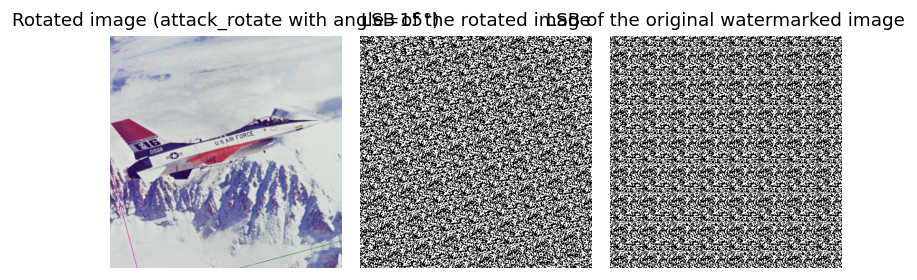

In [54]:
from lsb.model import encode as lsb_encode

watermarked_img = lsb_encode(images["airplane"], watermark, patch_size=32, key=SEED, tile_mode="normal")

rotate_img = attack_rotate(watermarked_img, angle=15.0)

lsb_rotated = rotate_img[:, :, 1] & 1  # LSB of the attacked image

lsb_original = watermarked_img[:, :, 1] & 1  # LSB of the original watermarked image

plt.figure()
plt.subplot(1, 3, 1)
plt.imshow(rotate_img)
plt.title("Rotated image (attack_rotate with angle=15°)")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.title("LSB of the rotated image")
plt.imshow(lsb_rotated, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.subplot(1, 3, 3)
plt.title("LSB of the original watermarked image")
plt.imshow(lsb_original, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.tight_layout()
plt.show()

## 13.1 · Visual check (correct LSB channel)

The `lsb.model.encode` function writes bits into the **green channel** (`channel=1`) for RGB images.
This diagnostic plot uses that channel explicitly so the watermark structure is visible.

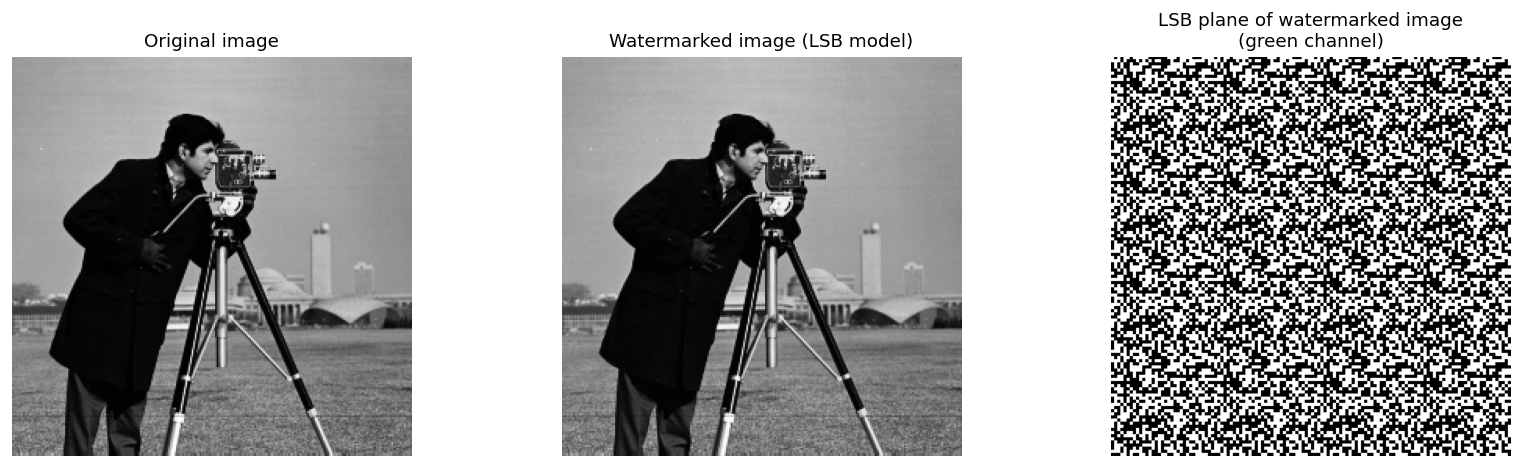

In [55]:
from skimage.util import img_as_ubyte
from lsb.model import encode as lsb_encode

img_name = "cameraman"
angle_deg = 15.0

src_img = img_as_ubyte(images[img_name])
watermarked_img = lsb_encode(src_img, watermark, patch_size=32, key=SEED, tile_mode="normal")

if watermarked_img.ndim == 3:
    lsb_watermarked = watermarked_img[..., 1] & 1  # green channel (encoder target)
else:
    lsb_watermarked = watermarked_img & 1

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(src_img, cmap="gray" if src_img.ndim == 2 else None)
ax[0].set_title("Original image")
ax[0].axis("off")

ax[1].imshow(watermarked_img, cmap="gray" if watermarked_img.ndim == 2 else None)
ax[1].set_title("Watermarked image (LSB model)")
ax[1].axis("off")

ax[2].imshow(lsb_watermarked, cmap="gray", vmin=0, vmax=1)
ax[2].set_title("LSB plane of watermarked image\n(green channel)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

253 6 uint8


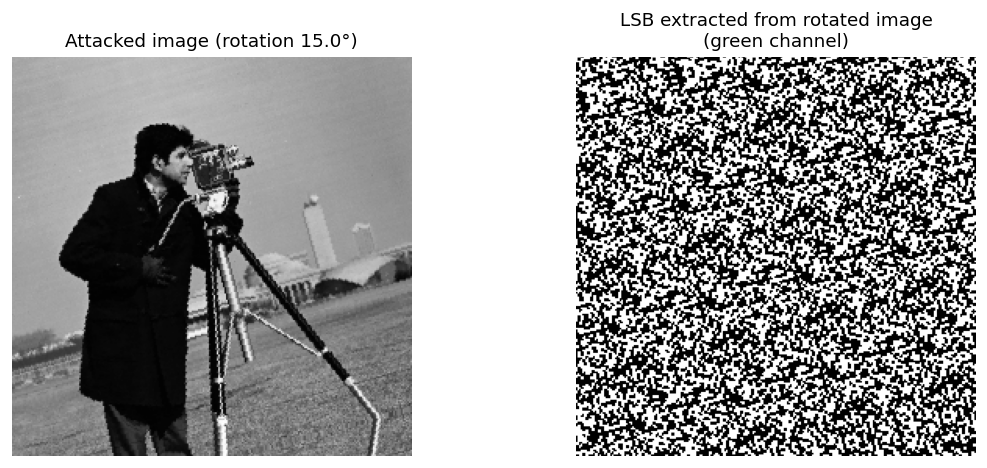

In [71]:
def attack_rotate(img: np.ndarray, angle: float = 15.0) -> np.ndarray:
    """Rotate by *angle* degrees (anti-clockwise, reflect padding)."""
    return rotate(img, angle, mode="reflect", order=0, preserve_range=True).astype(np.uint8)
print(np.max(watermarked_img), np.min(watermarked_img), watermarked_img.dtype)
rotated_img = attack_rotate(watermarked_img, angle=angle_deg)
rotated_u8 = img_as_ubyte(rotated_img)

if rotated_u8.ndim == 3:
    lsb_rotated = rotated_u8[..., 1] & 1  # same channel as embed
else:
    lsb_rotated = rotated_u8 & 1

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(rotated_u8, cmap="gray" if rotated_u8.ndim == 2 else None)
ax[0].set_title(f"Attacked image (rotation {angle_deg}°)")
ax[0].axis("off")

ax[1].imshow(lsb_rotated, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("LSB extracted from rotated image\n(green channel)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

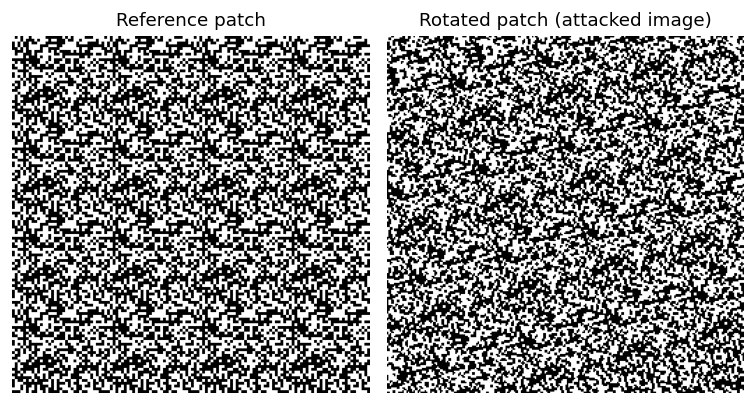

In [76]:
from utils.sync import synchronise, estimate_rotation_scale, estimate_translation, correct_rotation_scale, correct_translation
from utils.patch import build_reference_patch

ref = build_reference_patch(rotated_u8.shape, patch_size=32, key=SEED, tile_mode="normal")

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(ref, cmap="gray")
plt.title("Reference patch")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(lsb_rotated, cmap="gray")
plt.title("Rotated patch (attacked image)")
plt.axis("off")
plt.tight_layout()
plt.show()

Estimated rotation: -15.00°, scale: 1.0000


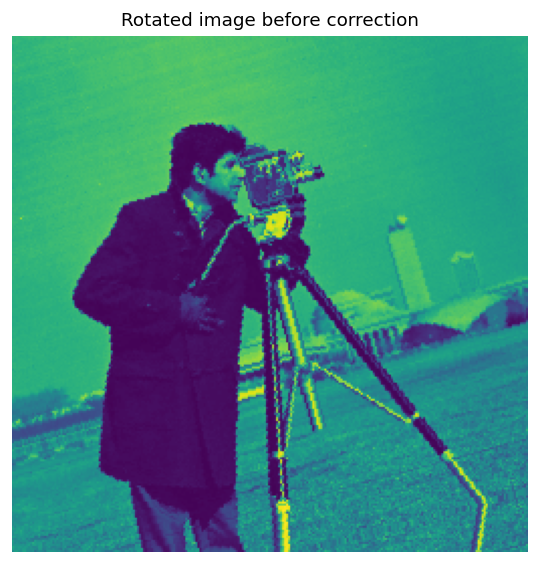

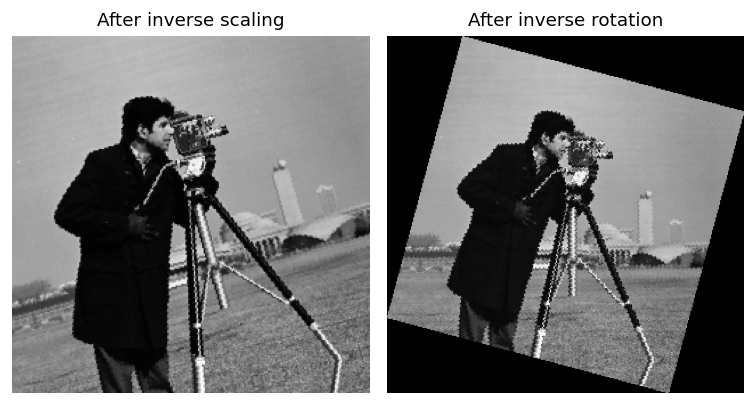

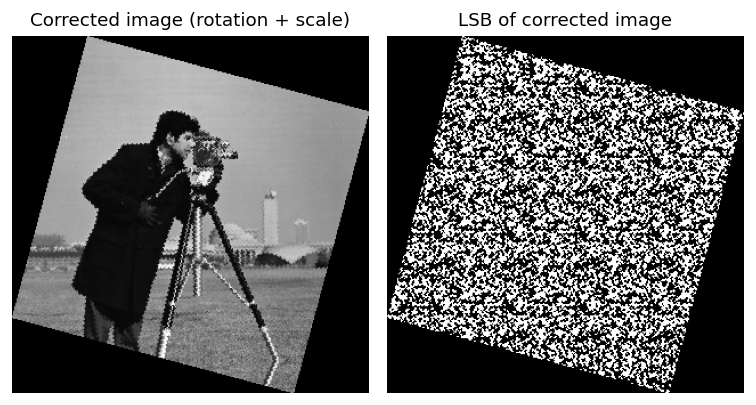

Estimated translation: (dx=29.00, dy=29.00)


In [100]:
angle, scale = estimate_rotation_scale(ref, lsb_rotated, upsample_factor=1)

print(f"Estimated rotation: {angle:.2f}°, scale: {scale:.4f}")

plt.figure()
plt.imshow(rotated_u8)
plt.title("Rotated image before correction")
plt.axis("off")
plt.tight_layout()
plt.show()

from skimage.transform import AffineTransform, warp
import numpy as np

import numpy as np
from skimage.transform import rescale, rotate


def crop_to_content(img: np.ndarray):
    """
    Crop using non-zero mask (robust for binary or grayscale).
    """
    mask = img > 0

    coords = np.argwhere(mask)
    if coords.size == 0:
        return img  # empty image

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    return img[y0:y1, x0:x1]


def correct_rotation_scale(image: np.ndarray, angle: float, scale: float):
    # 1. inverse scale
    img = rescale(
        image,
        1.0 / scale,
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    )

    # 2. inverse rotation (allow full geometry)
    img = rotate(
        img,
        angle,
        resize=True,
        order=0,
        mode="constant",
        cval=0,
        preserve_range=True,
    )

    # 3. remove padding completely
    img = crop_to_content(img)

    return img.astype(image.dtype)

corrected = correct_rotation_scale(rotated_u8, angle, scale)

manual_corrected_1 = rescale(rotated_u8, 1.0 / scale, order=0, preserve_range=True, anti_aliasing=False)
manual_corrected_2 = rotate(manual_corrected_1, angle, resize=True, order=0)

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(manual_corrected_1, cmap="gray" if manual_corrected_1.ndim == 2 else None)
plt.title("After inverse scaling")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(manual_corrected_2, cmap="gray" if manual_corrected_2.ndim == 2 else None)
plt.title("After inverse rotation")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(corrected, cmap="gray" if corrected.ndim == 2 else None)
plt.title("Corrected image (rotation + scale)")
plt.axis("off")
plt.subplot(1, 2, 2)
corrected_lsb = corrected[..., 1] & 1 if corrected.ndim == 3 else corrected & 1
plt.imshow(corrected_lsb, cmap="gray", vmin=0, vmax=1)
plt.title("LSB of corrected image")
plt.axis("off")
plt.tight_layout()
plt.show()

ref_translation = build_reference_patch(corrected_lsb.shape, patch_size=32, key=SEED, tile_mode="normal")
translation = estimate_translation(ref_translation, corrected_lsb, upsample_factor=1)
print(f"Estimated translation: (dx={translation[0]:.2f}, dy={translation[1]:.2f})")


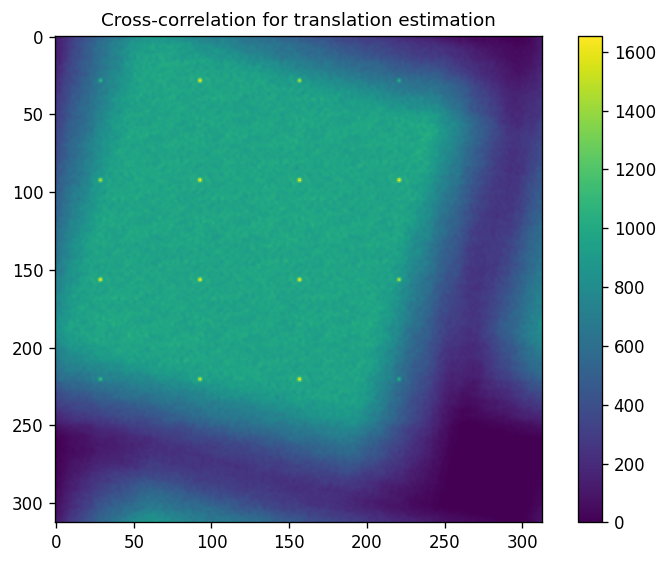

ValueError: images must be same shape

In [101]:
from utils.patch import generate_base_patch, upsample_patch
from skimage.registration import phase_cross_correlation

base_patch = generate_base_patch(32, key=SEED)
upsampled_patch = upsample_patch(base_patch)

F = np.fft.fft2(corrected_lsb)
H = np.fft.fft2(upsampled_patch, s=corrected_lsb.shape)

corr = np.fft.ifft2(F * np.conj(H)).real

plt.figure()
plt.imshow(corr, cmap="viridis")
plt.title("Cross-correlation for translation estimation")
plt.colorbar()
plt.tight_layout()
plt.show()

print(f"translation factor: {phase_cross_correlation(corrected_lsb, upsampled_patch, upsample_factor=1)}")